## Genomics

Leukemia is a cancer of blood-generating tissues. Over 475,000 Americans have Leukemia or are in remission from it. It accounts for 3.3% of all new cancer cases and 3.8% of cancer deaths, with an estimated 66,890 new cases and 23,540 deaths in the U.S. in 2025.

There are two major leukemia families: Acute Lymphoblastic Leukemia (ALLB and ALLT, or ALL), which is cancer of immature lymphoid cells, and Acute Myeloid Leukemia (AML), which is cancer of cancer of immature myeloid cells.

Golub et al. (*Science*, 1999) popularized a dataset including about 7000 genes from 72 patients. The goal is to use genomics data to predict which patients are at risk of ALL versus AML, because the distinction is critical for timely and effective treatment.

In [278]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LinearRegression, Lasso, LassoCV
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import cross_val_score, KFold
from sklearn.preprocessing import StandardScaler


1. Load the `golub.csv` dataset. Relabel all instances of ALLB and ALLT as 0, and all instances of ALL as 1. This is the target variable. 

In [279]:
# loading data 
data = pd.read_csv("data/golub.csv")

# data inspection
display(data.head())
display(data.describe())
display(data.shape)

# relabel all instances
data["target"] = data["cancer"].replace({
    "allB": 0,
    "allT": 0,
    "aml": 1
})

display(data.head())


,Samples,BM.PB,Gender,Source,tissue.mf,cancer,AFFX-BioB-5_at,AFFX-BioB-M_at,AFFX-BioB-3_at,AFFX-BioC-5_at,...,U48730_at,U58516_at,U73738_at,X06956_at,X16699_at,X83863_at,Z17240_at,L49218_f_at,M71243_f_at,Z78285_f_at
0,39,BM,F,DFCI,BM:f,allB,-1363.276427,-1058.585495,-541.469194,74.349803,...,-35.081447,1565.618803,-485.680714,-170.261227,-919.114293,1675.050053,389.769289,-526.449219,-268.963924,-779.643092
1,40,BM,F,DFCI,BM:f,allB,-796.285053,-1167.103365,7.538493,83.544731,...,-404.737767,622.498054,-1275.354673,214.828233,-750.220666,-441.589276,9.841713,-671.911209,-671.911209,-644.272577
2,42,BM,F,DFCI,BM:f,allB,-679.139168,-1069.832308,-690.301829,-112.075981,...,193.780934,162.525483,-692.534361,517.498108,-674.674103,1265.396405,-65.192805,-714.859684,3672.066149,-822.021231
3,47,BM,M,DFCI,BM:m,allB,-1164.400197,-1109.939891,-990.127218,-238.574994,...,-256.002292,-31.625831,-621.975549,-458.594630,-630.689198,937.767618,-264.715941,-635.046022,475.944222,-794.070116
4,48,BM,F,DFCI,BM:f,allB,-1299.653758,-1401.998536,-1077.543813,-437.344560,...,-509.203660,383.591216,-905.517483,-36.675640,-1116.739685,316.087213,-210.879518,-953.423549,-291.448812,-1057.945876


,Samples,AFFX-BioB-5_at,AFFX-BioB-M_at,AFFX-BioB-3_at,AFFX-BioC-5_at,AFFX-BioC-3_at,AFFX-BioDn-5_at,AFFX-BioDn-3_at,AFFX-CreX-5_at,AFFX-CreX-3_at,...,U48730_at,U58516_at,U73738_at,X06956_at,X16699_at,X83863_at,Z17240_at,L49218_f_at,M71243_f_at,Z78285_f_at
count,72.00000,72.000000,72.000000,72.000000,72.000000,72.000000,72.000000,72.000000,72.000000,72.000000,...,72.000000,72.000000,72.000000,72.000000,72.000000,72.000000,72.000000,72.000000,72.000000,72.000000
mean,36.50000,-977.984015,-1074.922653,-745.652538,-318.872693,-1278.507478,-1589.462935,-867.148751,-1142.660290,-554.004911,...,-346.478763,721.424115,-753.560766,111.889548,-801.798762,962.667369,-68.713830,-707.652813,207.947055,-795.113934
std,20.92845,278.712664,259.836997,327.995987,243.925915,322.785101,380.353938,631.438568,283.637310,248.301704,...,213.973723,606.248404,234.001460,856.058252,184.760851,926.774851,432.412482,153.816444,1367.034854,182.878694
min,1.00000,-2010.202020,-1771.325849,-1587.702224,-878.403453,-1862.549643,-2460.641168,-2766.759937,-1688.485698,-1255.146509,...,-822.208255,-375.241836,-1484.465401,-853.838447,-1367.829068,-507.543374,-807.704074,-1162.232820,-1132.077868,-1298.638023
25%,18.75000,-1143.648114,-1248.485464,-974.963422,-520.608763,-1490.736175,-1820.986210,-1257.579378,-1341.951576,-685.412742,...,-501.930177,296.517532,-905.620872,-258.719639,-947.423419,302.817909,-338.852621,-810.729951,-465.630253,-918.737765
50%,36.50000,-916.324704,-1064.208902,-709.111943,-286.175829,-1281.167476,-1610.173503,-875.611028,-1118.930360,-533.215679,...,-374.304436,648.259975,-769.368677,-24.865385,-784.272729,796.877522,-200.986188,-705.795842,-250.421310,-786.856604
75%,54.25000,-792.417968,-873.417830,-572.454089,-192.349880,-1080.583259,-1275.377441,-539.967722,-977.181834,-392.027648,...,-215.497051,1059.214217,-597.298233,218.017618,-659.133460,1561.557440,148.990351,-584.930527,46.009589,-672.904574
max,72.00000,-385.768608,-574.604197,130.829434,221.803330,-312.866984,-899.769814,854.344470,-487.454105,116.283984,...,193.780934,2482.375600,-248.296470,5068.461316,-437.092239,3989.060948,1284.266900,-438.329336,5845.204223,-326.423100


(72, 7135)

/var/folders/t6/fdg24_1x5970273s9fgndyg40000gn/T/ipykernel_65319/1930616344.py:10: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  data["target"] = data["cancer"].replace({


,Samples,BM.PB,Gender,Source,tissue.mf,cancer,AFFX-BioB-5_at,AFFX-BioB-M_at,AFFX-BioB-3_at,AFFX-BioC-5_at,...,U58516_at,U73738_at,X06956_at,X16699_at,X83863_at,Z17240_at,L49218_f_at,M71243_f_at,Z78285_f_at,target
0,39,BM,F,DFCI,BM:f,allB,-1363.276427,-1058.585495,-541.469194,74.349803,...,1565.618803,-485.680714,-170.261227,-919.114293,1675.050053,389.769289,-526.449219,-268.963924,-779.643092,0
1,40,BM,F,DFCI,BM:f,allB,-796.285053,-1167.103365,7.538493,83.544731,...,622.498054,-1275.354673,214.828233,-750.220666,-441.589276,9.841713,-671.911209,-671.911209,-644.272577,0
2,42,BM,F,DFCI,BM:f,allB,-679.139168,-1069.832308,-690.301829,-112.075981,...,162.525483,-692.534361,517.498108,-674.674103,1265.396405,-65.192805,-714.859684,3672.066149,-822.021231,0
3,47,BM,M,DFCI,BM:m,allB,-1164.400197,-1109.939891,-990.127218,-238.574994,...,-31.625831,-621.975549,-458.594630,-630.689198,937.767618,-264.715941,-635.046022,475.944222,-794.070116,0
4,48,BM,F,DFCI,BM:f,allB,-1299.653758,-1401.998536,-1077.543813,-437.344560,...,383.591216,-905.517483,-36.675640,-1116.739685,316.087213,-210.879518,-953.423549,-291.448812,-1057.945876,0


2. Use Linear Regression of the target variable on all of the genes provided. What is your mean squared error? Make a kernel density plot of your residuals, and a scatter plot comparing predicted and actual outcomes. 

Mean Squared Error: 6.765406708643482e-30


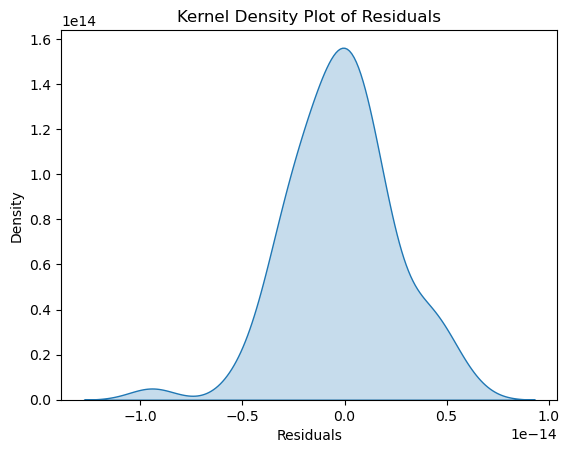

Text(0.5, 1.0, 'Predicted vs Actual')

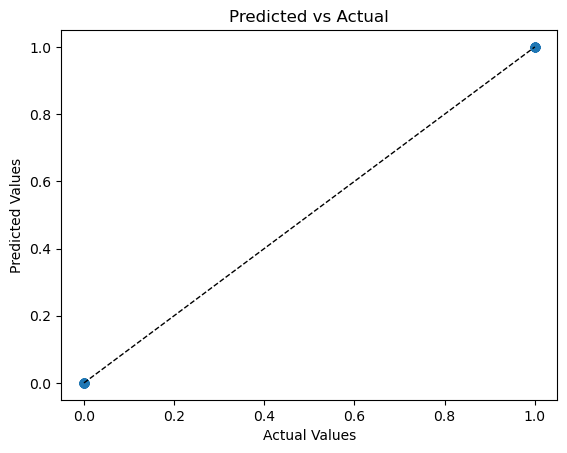

In [287]:
# data cleanse
feature_cols = ["Samples", "BM.PB", "Gender", "Source", "tissue.mf", "cancer", "target"]
X = data.drop(columns=feature_cols)
y = data["target"]

# linear regression
model = LinearRegression()
model.fit(X,y)
y_pred = model.predict(X)
residuals = y_pred - y

# mean squared error
mse = mean_squared_error(y, y_pred)
print("Mean Squared Error:", mse)

# kernel density plot
sns.kdeplot(residuals, fill=True)
plt.title("Kernel Density Plot of Residuals")
plt.xlabel("Residuals")
plt.ylabel("Density")
plt.show()

# scatter plot
plt.scatter(y, y_pred)
plt.plot([0, 1], [0, 1], linestyle='--', color='black', linewidth=1)
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Predicted vs Actual")



The mean squared error is 6.765406708643482e-30. It is close to zero which means the model almost perfectly fits on the training data.

3. Use cross validation to compute the mean squared error of the linear model. Discuss your results from the perspective of the bias variance trade-off.

In [281]:
# cross validation
kfold = KFold(n_splits=5, shuffle=True, random_state=100)
scores = cross_val_score(model, X, y, cv=kfold, scoring='neg_mean_squared_error')
mse_scores = -scores

print("MSE for each fold:", mse_scores)
print("Average MSE:", np.mean(mse_scores))

MSE for each fold: [0.0244198  0.05792023 0.09224999 0.02097934 0.02126042]
Average MSE: 0.043365958986227957


The linear regression model shows a extremely low training mean squared error (5.37 x 10e-30) which means that the training data is almost perfect. However, the cross-validated mean squared error is significantly higher (approximately 0.060), which reveals poor generalization to unseen data. From the bias–variance tradeoff perspective, this indicates that the model has low bias but high variance.

4. Use the cross validated LASSO to select a set of highly predictive genes. Which set of genes is selected? How many genes are discarded from the model? Make a scatterplot of your predictions versus the actual values. 

In [282]:
# standardize
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# fit cross validate LASSO
alpha_grid = np.logspace(-4, -2, num=50)
lasso_cv = LassoCV(cv=10, alphas=alpha_grid, random_state=100, max_iter=10000)
lasso_cv.fit(X_scaled, y)

alpha_star = lasso_cv.alpha_
mean_mse_path = np.mean(lasso_cv.mse_path_, axis=1)
index_star = np.argmin(mean_mse_path)

coefs = []
for alpha in lasso_cv.alphas_:
    model = Lasso(alpha=alpha, max_iter=10000)
    model.fit(X_scaled, y)
    coefs.append(model.coef_)
coefs = np.array(coefs)

coefs_star = coefs[index_star]
selected_idx = np.nonzero(coefs_star)[0]
selected_genes = X.columns[selected_idx].tolist()

lasso_star = Lasso(alpha=alpha_star, max_iter=10000).fit(X_scaled, y)
y_pred_lasso = lasso_star.predict(X_scaled)

print(f'Optimal alpha: {alpha_star:.10f}')
print(f'Selected genes: {len(selected_genes)}')
print(f'Discarded genes: {X.shape[1] - len(selected_genes)}')
print(selected_genes)




Optimal alpha: 0.0016768329
Selected genes: 70
Discarded genes: 7059
['AF000560_at', 'AF006087_at', 'D26579_at', 'D29956_at', 'D42043_at', 'D50840_at', 'D86982_at', 'HG2161-HT2231_at', 'J04101_at', 'J04164_at', 'L13278_at', 'M17754_at', 'M19507_at', 'M20902_at', 'M22960_at', 'M23197_at', 'M27819_at', 'M27891_at', 'M28713_at', 'M31994_at', 'M34344_at', 'M63138_at', 'M84526_at', 'M95178_at', 'M96326_rna1_at', 'M98539_at', 'U10868_at', 'U14588_at', 'U30828_at', 'U34877_at', 'U36621_cds2_at', 'U46751_at', 'U50136_rna1_at', 'U51127_at', 'U60062_at', 'U82313_at', 'U82759_at', 'U89942_at', 'X04143_at', 'X14789_at', 'X16706_at', 'X53331_at', 'X56741_at', 'X63753_at', 'X66533_at', 'X69111_at', 'X81479_at', 'X83378_at', 'X95735_at', 'X96698_at', 'Y07604_at', 'Y07755_at', 'Y10207_at', 'Y12670_at', 'M96843_at', 'X58072_at', 'AC002477_s_at', 'L15326_s_at', 'X57351_at', 'U37055_rna1_s_at', 'X07438_s_at', 'M13690_s_at', 'M26708_s_at', 'M84371_rna1_s_at', 'X12876_s_at', 'U26312_s_at', 'X85116_rna1_s_a

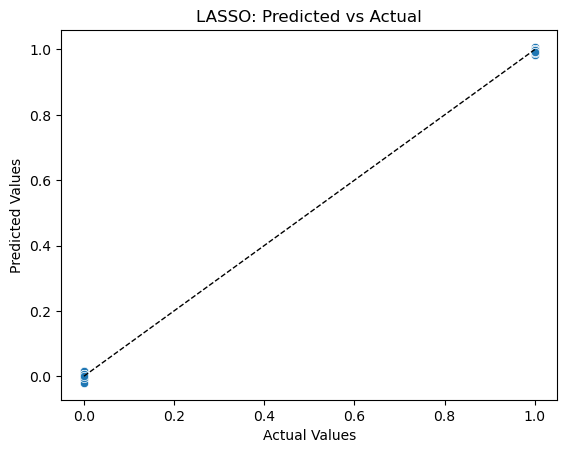

Main Squared Error:  4.642794416477629e-05


In [286]:
# scatter
sns.scatterplot(x=y, y=y_pred_lasso)
plt.plot([0, 1], [0, 1], linestyle='--', color='black', linewidth=1)
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("LASSO: Predicted vs Actual")
plt.show()

mse = mean_squared_error(y, y_pred_lasso)
print("Main Squared Error: ", mse)

7059 Genes are Discarded

5. Make a plot that shows the cross validated MSE as $alpha$ varies. For what values of $\alpha$ is the LASSO underfitting? Overfitting? What is the optimal penality hyperparameter that minimizes expected MSE?

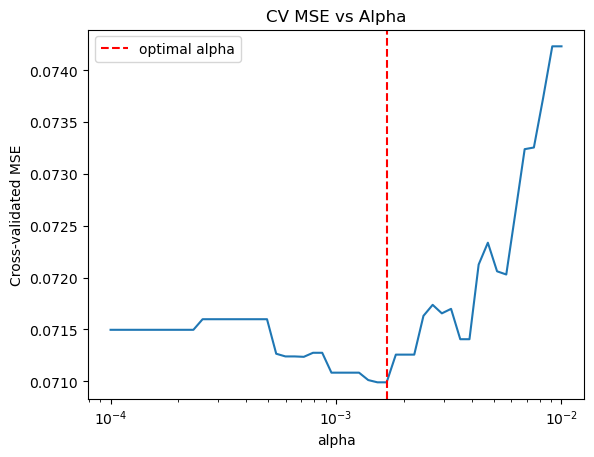

Optimal alpha: 0.0016768329368110067


In [284]:
# plot
sns.lineplot(x=lasso_cv.alphas_, y=mean_mse_path)
plt.xscale("log")
plt.xlabel("alpha")
plt.ylabel("Cross-validated MSE")
plt.title("CV MSE vs Alpha")
plt.axvline(lasso_cv.alpha_, color='red', linestyle='--', label='optimal alpha')
plt.legend()
plt.show()

print("Optimal alpha:", lasso_cv.alpha_)


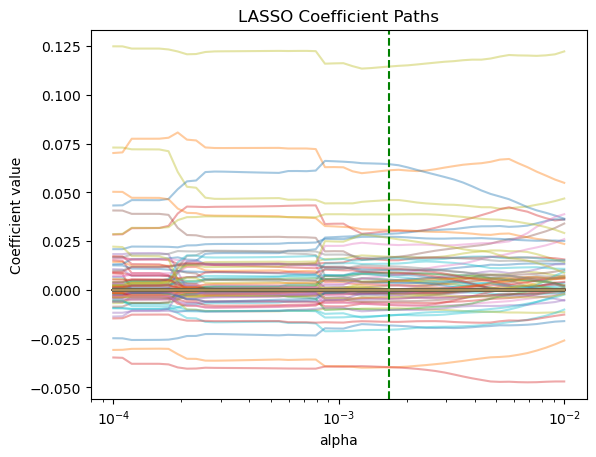

In [285]:
for i in range(coefs.shape[1]):
    plt.plot(lasso_cv.alphas_, coefs[:, i], alpha=0.4)
plt.xscale('log')
plt.axvline(alpha_star, color='green', linestyle='--')
plt.xlabel('alpha')
plt.ylabel('Coefficient value')
plt.title('LASSO Coefficient Paths')
plt.show()

Smaller alpha on the right side did not shrink much of the coefficients in the model, which causes over-fitting. The large values of alpha on the left side of the graph shrink too much coefficient causing the model to underfit.  The minimum expected error occurs at approximately 0.001677.

6. Explain why linear regression performs perfectly on the training set, but the LASSO provides better predictions overall.

The linear regression performs perfectly on the training set because the dataset has more features than observations, allowing the model to fit the data with many coefficients, but this leads to high variance and poor generalization. The LASSO model introduces regularization, which reduces variance by shrinking and eliminating coefficients, thereby improving generalization to unseen data.

7. Why do regularization methods lend themselves to scenarios like precision health? 

Because precision health often has high-dimensional, but low-sample data. In this case, there are roughly 7000 features. The standard models tend to overfit and produce unstable estimates. If we try to find all of their relationship or interactions, the problem will not only be extremely complicated, and the result will be less reliable. Therefore, regularization methods like LASSO can reduce our focus to a smaller subset of data and interactions, making such research easier to conduct.

8. What are the risks of applying methods like the Lasso to precision health questions, where interventions will then be taken to optimize patient health?

The predications are not based on cause and effect relationship. It is simply statistical association in the data, which means that the model cannot determine whether particular gene causes a disease or certain outcome. It only identifies genes that are correlated with it. Therefore, interventions based on these prediction may be ineffective or even harmful, since changing a correlated feature does not necessarily change the underlying condition.